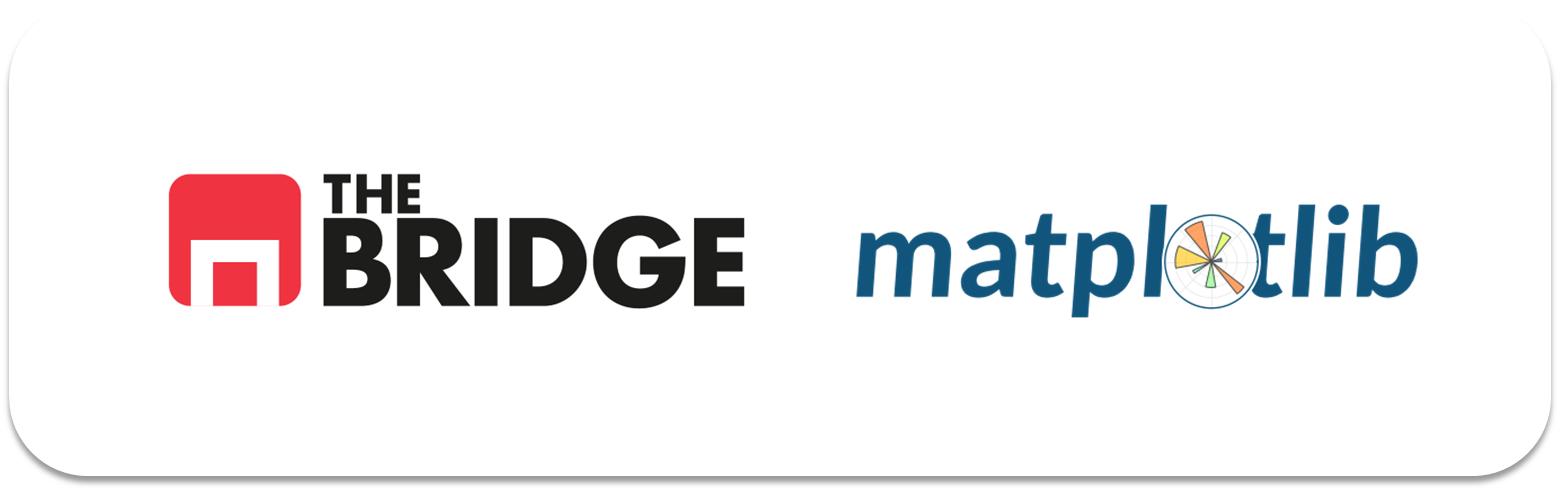

## PRACTICA OBLIGATORIA: **Visualización Básica**

* La práctica obligatoria de esta unidad consiste en un único ejercicio de construcción de gráficas. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

### Ejercicio 1

#### #1.1

- Carga el dataset de casas de California que está en la ruta "./data/california_cities.csv".  
- Muestra parte de su contenido y su descripción.  
- Deshazte de las filas con nulos.

In [6]:
df_cal = pd.read_csv("./data/california_cities.csv")

In [7]:
df_cal.sample(5)

,Unnamed: 0,city,latd,longd,elevation_m,elevation_ft,population_total,area_total_sq_mi,area_land_sq_mi,area_water_sq_mi,area_total_km2,area_land_km2,area_water_km2,area_water_percent
461,461,WestlakeVillage,34.141944,-118.819444,268.0,880.0,8270,5.509,5.185,0.320,14.257,13.430,0.828,5.80
337,337,RanchoSantaMargarita,33.641389,-117.594444,290.0,775.0,47853,12.992,12.957,0.035,33.651,33.560,0.091,0.27
332,332,Poway,32.970000,-117.038611,157.0,515.0,47811,39.165,39.079,0.086,101.438,101.214,0.223,0.22
177,177,HiddenHills,34.167500,-118.660833,328.0,1076.0,1856,1.689,1.689,0.000,4.373,4.373,0.000,0.00
45,45,Brawley,32.978611,-115.530278,-34.0,-112.0,24953,7.682,7.682,0.000,19.895,19.895,0.000,0.00


In [8]:
df_cal.describe()

,Unnamed: 0,latd,longd,elevation_m,elevation_ft,population_total,area_total_sq_mi,area_land_sq_mi,area_water_sq_mi,area_total_km2,area_land_km2,area_water_km2,area_water_percent
count,482.000000,482.000000,482.000000,434.000000,470.000000,4.820000e+02,480.000000,482.000000,481.000000,477.000000,478.000000,478.000000,477.000000
mean,240.500000,36.095088,-119.837714,180.416705,567.168723,6.489493e+04,18.442183,16.840981,1.589630,46.753283,43.547021,3.125178,5.301801
std,139.285678,2.298006,2.147676,309.531825,1001.265722,2.032041e+05,36.363230,32.694647,9.490386,90.972269,84.933022,11.562269,14.656428
min,0.000000,32.578333,-124.263333,-34.000000,-180.000000,1.000000e+00,0.314000,0.314000,0.000000,0.813000,0.813000,0.000000,0.000000
25%,120.250000,33.977292,-121.954931,22.000000,69.000000,1.090200e+04,3.708250,3.506500,0.000000,9.551000,9.025000,0.000250,0.000000
50%,240.500000,36.204722,-119.708611,67.000000,200.000000,2.905750e+04,9.093000,8.362000,0.029000,23.551000,21.533000,0.078500,0.340000
75%,360.750000,37.886667,-117.977292,173.500000,515.000000,6.646650e+04,19.878250,19.090000,0.244000,51.772000,49.322000,0.623250,1.870000
max,481.000000,41.965000,-114.596389,2402.000000,7880.000000,3.884307e+06,503.000000,469.000000,185.020000,1302.000000,1214.000000,122.270000,84.580000


In [9]:
df_cal.dropna(inplace = True)

#### #1.2  

Recrea la siguiente figura, para ello construye en apartados separados cada gráfico y luego haz un apartado en el que se junten los cuatro.  

Las figuras son:
1. Las ciudades más pobladas, con los numeros de las poblaciones (tendrás que usar texto y recordar que para centrarlos se necesita poner el argumento `ha` a "center" o investigar como funciona bar_label). Los colores de las barras deben tener un 50% de transparencia y ser: azul, gris, rojo, aceituna y marrón.  

2. Histograma del área total ocupada por las ciudades. (50 bins, fuente = "Arial", tamaño = 14, peso = "Bold", color azul acero o "steelblue")
3. El scatter de área de agua de un ciudad con su poblacion. Transparencia al 50% y color verde.
4. El boxplot de la altura de las ciudades.

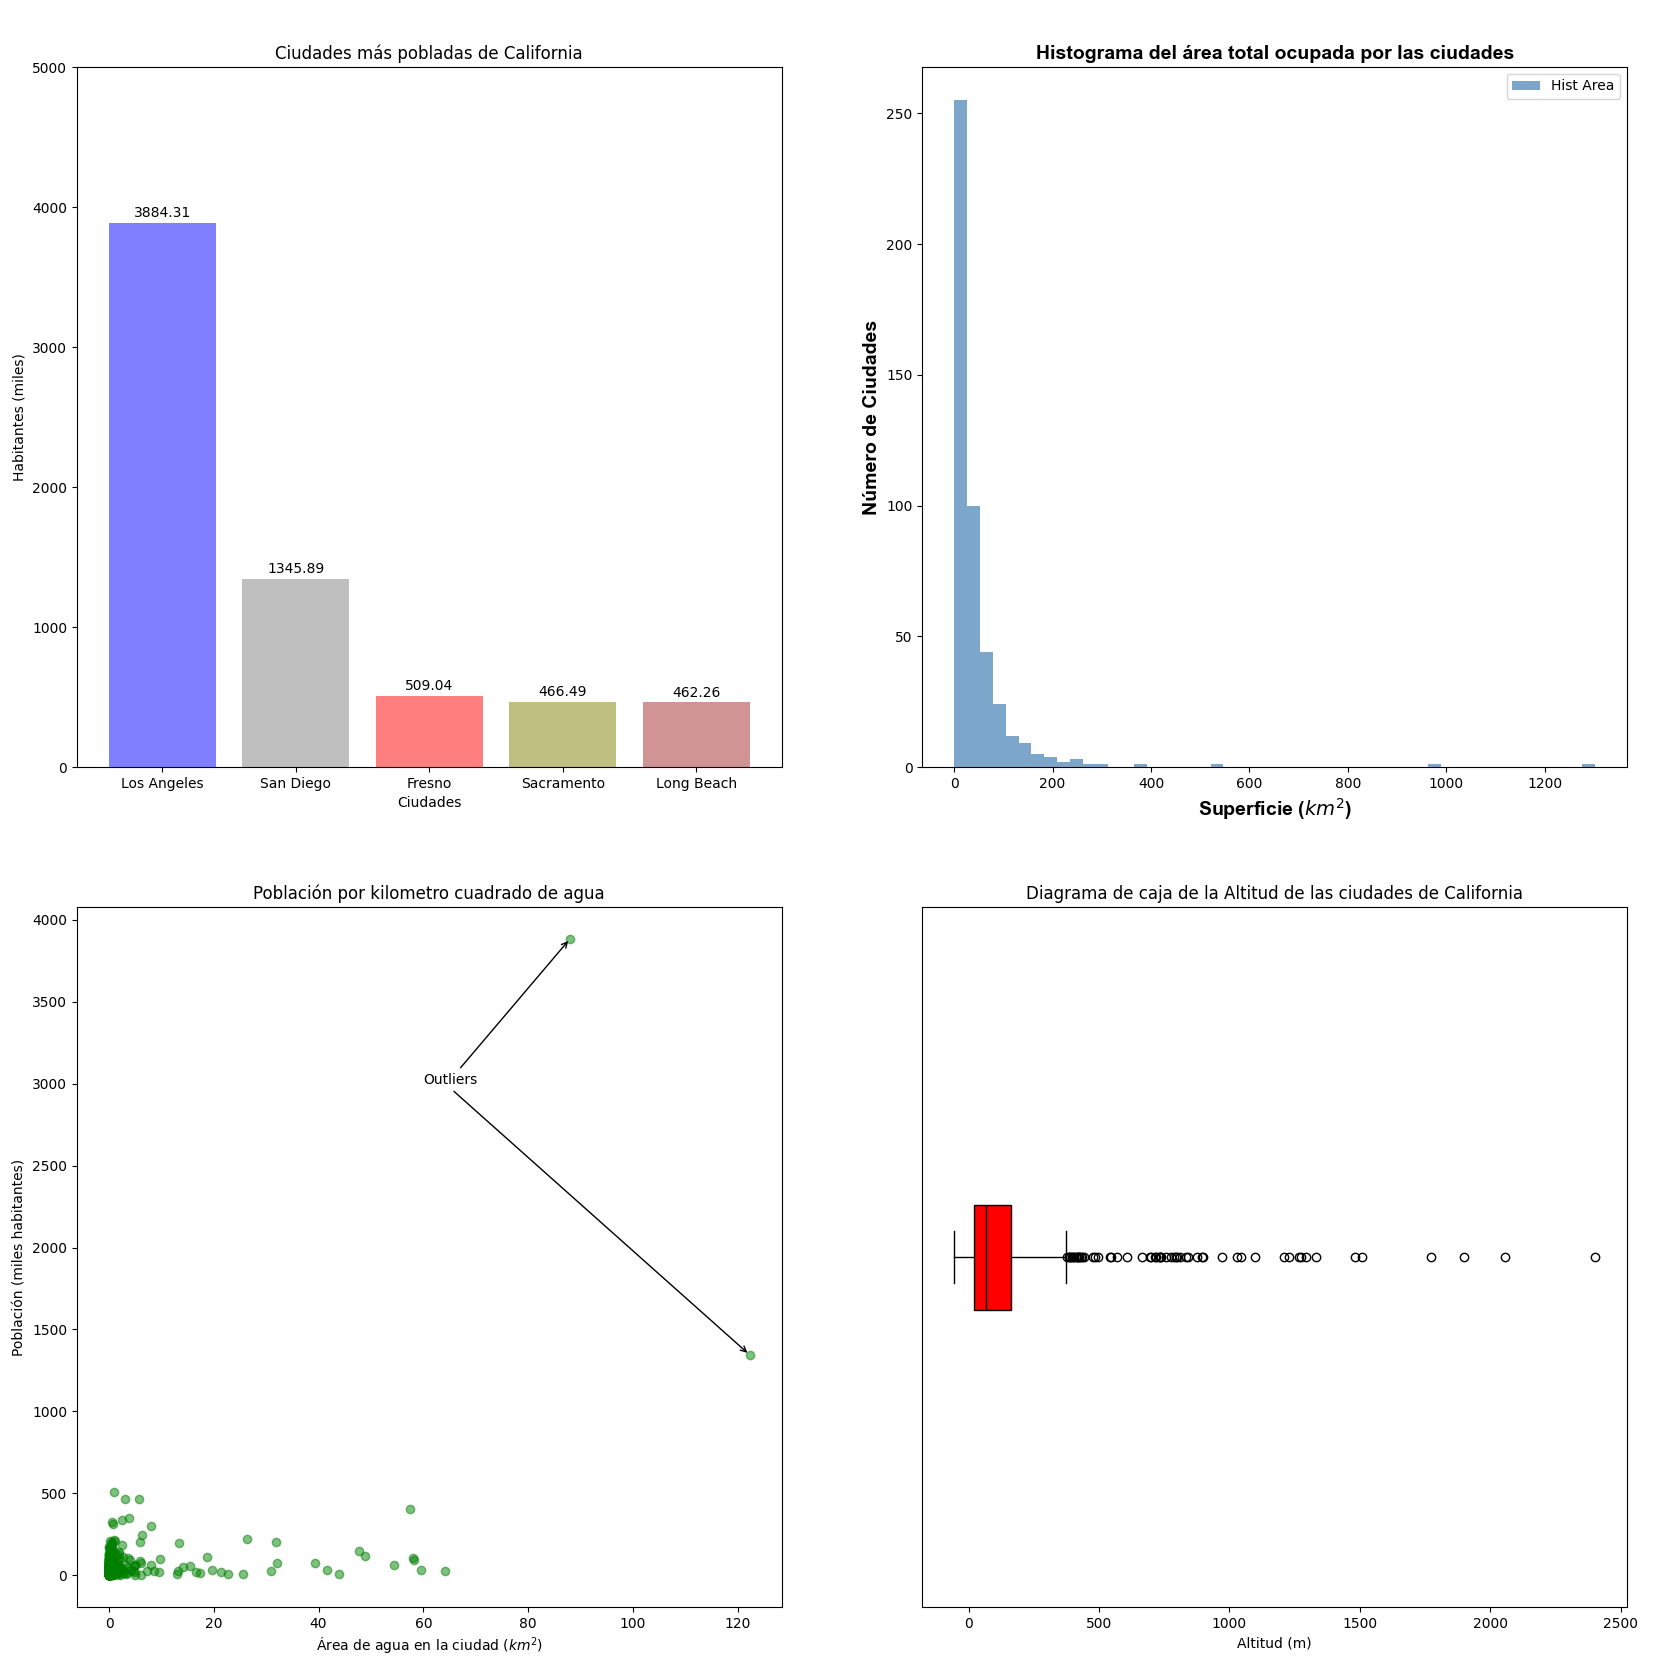

### Gráfico de barras de las ciudades más pobladas de California

In [12]:
df_ciudades = df_cal[["city", "population_total"]].nlargest(5, "population_total").copy()
df_ciudades["population_miles"] = df_ciudades["population_total"] / 1000
df_ciudades["city"] = ["Los Angeles", "San Diego", "Fresno", "Sacramento", "Long Beach"]


In [ ]:
def grafico_poblacion(df):
    fig, ax = plt.subplots(figsize=(8, 6))

    barras = ax.bar(df["city"], df["population_miles"], color=["blue", "gray", "red", "olive", "brown"], alpha=0.5)

    ax.bar_label(barras, fmt="%.2f", padding=2)
    ax.set_ylim(0, 5000)

    ax.set_title("Ciudades más pobladas de California")
    ax.set_xlabel("Ciudades")
    ax.set_ylabel("Habitantes (miles)")

    plt.show()
    return

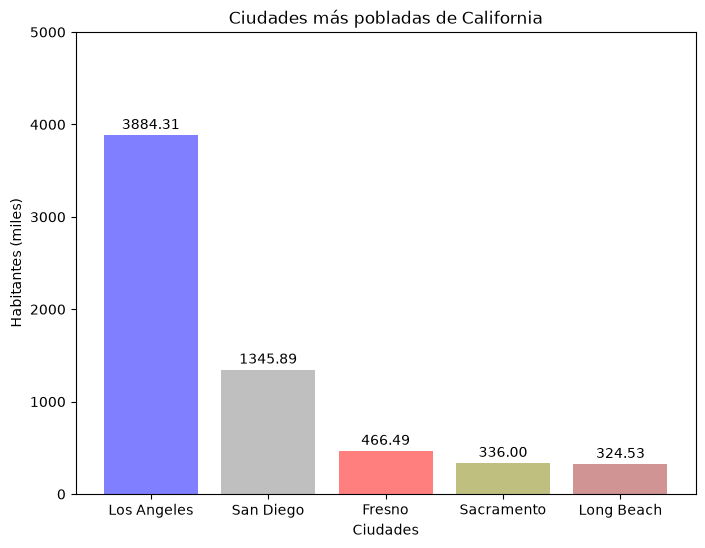

In [16]:
grafico_poblacion(df_ciudades)

### Histograma del área total ocupada por las ciudades

In [ ]:
def histograma(df):
    fig, ax = plt.subplots(figsize=(8, 6))

    ax.hist(df["area_total_km2"], bins=50, color="steelblue", alpha=0.7, label="Hist Area")

    ax.set_title("Histograma del área total ocupada por las ciudades", font="Arial", fontsize=14, fontweight="bold")
    ax.set_xlabel("Superficie ($km^2$)")
    ax.set_ylabel("Número de Ciudades")
    ax.legend()

    plt.show()
    return

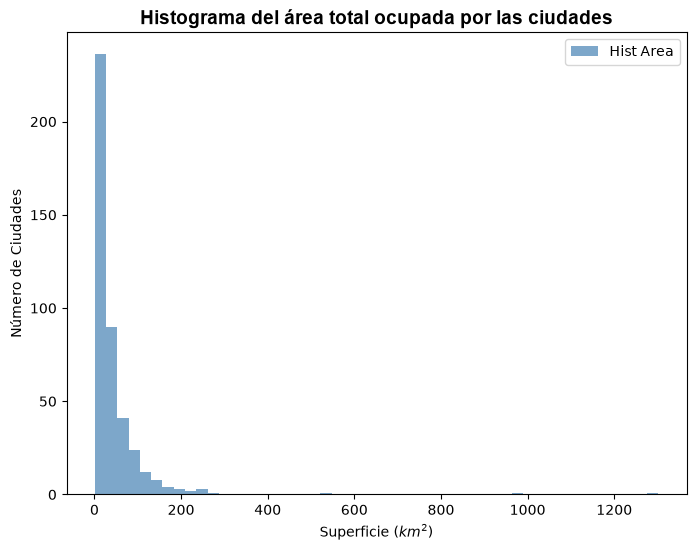

In [20]:
histograma(df_cal)

### Diagrama de dispersión de la población por kilómetro cuadrado de agua

In [21]:
df_dispersion = df_cal[["area_water_km2", "population_total"]].copy()
df_dispersion["population_miles"] = df_dispersion["population_total"] / 1000
outliers = df_dispersion.nlargest(2, "population_total")

In [37]:
def diagrama_dispersion(df_dispersion, outliers):
    fig, ax = plt.subplots(figsize=(8, 6))

    ax.scatter(df_dispersion["area_water_km2"], df_dispersion["population_miles"],
               color="green", alpha=0.5)

    ax.set_title("Población por kilometro cuadrado de agua")
    ax.set_xlabel("Área de agua en la ciudad ($km^2$)")
    ax.set_ylabel("Población (miles habitantes)")

    ax.annotate("Outliers",
                xy=(outliers.iloc[0]["area_water_km2"],
                    outliers.iloc[0]["population_miles"]),
                xytext=(60, 3000),
                arrowprops={"arrowstyle": "->"})

    ax.annotate("",
                xy=(outliers.iloc[1]["area_water_km2"],
                    outliers.iloc[1]["population_miles"]),
                xytext=(68, 2960),
                arrowprops={"arrowstyle": "->"})

    plt.show()
    return

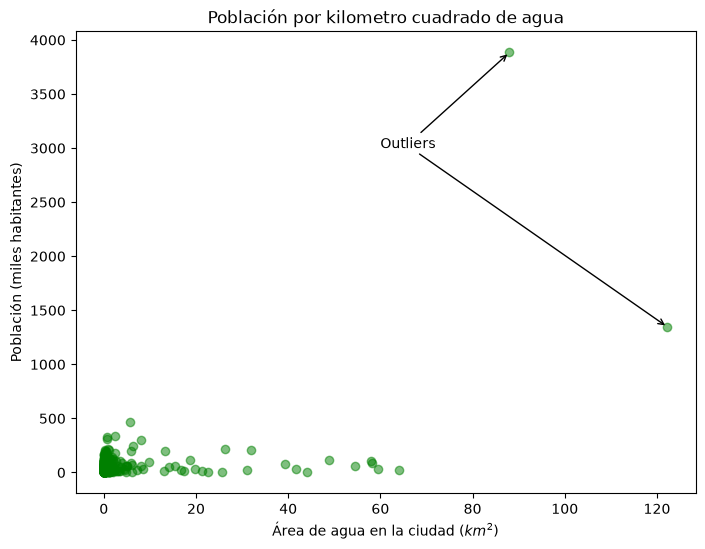

In [38]:
diagrama_dispersion(df_dispersion, outliers)

### Boxplot de la altitud de las ciudades en California

In [ ]:
def boxplot(df):
    fig, ax = plt.subplots(figsize=(8, 6))

    ax.boxplot(df["elevation_m"], orientation = "horizontal", patch_artist=True,
               boxprops={"facecolor": "red"}, medianprops={"color": "black"})

    ax.set_title("Diagrama de caja de la Altitud de las ciudades de California")
    ax.set_xlabel("Altitud (m)")
    ax.set_yticks([])

    plt.show()

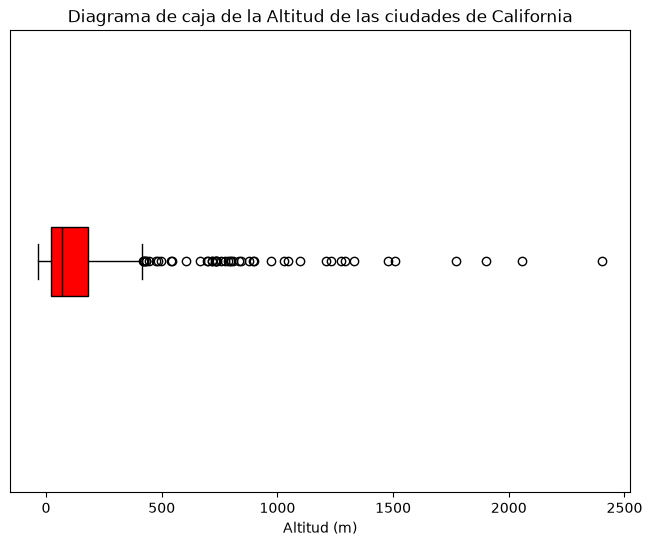

In [47]:
boxplot(df_cal)

### Juntamos todas las figuras y las guardamos

In [49]:
def figura_conjunta(df, df_ciudades, df_dispersion, outliers, guardar = False):
    fig, axes = plt.subplots(2, 2, figsize=(20, 20))

    # Gráfico barras
    barras = axes[0, 0].bar(df_ciudades["city"], df_ciudades["population_miles"],
        color=["blue", "gray", "red", "olive", "brown"], alpha=0.5)

    axes[0, 0].bar_label(barras, fmt="%.2f", padding=2)
    axes[0, 0].set_ylim(0, 5000)

    axes[0, 0].set_title("Ciudades más pobladas de California")
    axes[0, 0].set_xlabel("Ciudades")
    axes[0, 0].set_ylabel("Habitantes (miles)")

    # Histograma
    axes[0, 1].hist(df["area_total_km2"], bins=50, color="steelblue", alpha=0.7, label="Hist Area")

    axes[0, 1].set_title("Histograma del área total ocupada por las ciudades", font="Arial", fontsize=14, fontweight="bold")
    axes[0, 1].set_xlabel("Superficie ($km^2$)")
    axes[0, 1].set_ylabel("Número de Ciudades")
    axes[0, 1].legend()

    # Diagrama dispersión
    axes[1, 0].scatter(df_dispersion["area_water_km2"], df_dispersion["population_miles"],
        color="green", alpha=0.5)

    axes[1, 0].set_title("Población por kilometro cuadrado de agua")
    axes[1, 0].set_xlabel("Área de agua en la ciudad ($km^2$)")
    axes[1, 0].set_ylabel("Población (miles habitantes)")

    axes[1, 0].annotate("Outliers",
                        xy=(outliers.iloc[0]["area_water_km2"],
                            outliers.iloc[0]["population_miles"]),
                        xytext=(60, 3000),
                        arrowprops={"arrowstyle": "->"})

    axes[1, 0].annotate("",
                        xy=(outliers.iloc[1]["area_water_km2"],
                            outliers.iloc[1]["population_miles"]),
                        xytext=(68, 2960),
                        arrowprops={"arrowstyle": "->"})

    # Boxplot
    axes[1, 1].boxplot(df["elevation_m"], orientation = "horizontal", patch_artist=True,
        boxprops={"facecolor": "red"}, medianprops={"color": "black"}    )

    axes[1, 1].set_title("Diagrama de caja de la Altitud de las ciudades de California")
    axes[1, 1].set_xlabel("Altitud (m)")
    axes[1, 1].set_yticks([])

    plt.tight_layout()
    if guardar: plt.savefig(f"./recursos/figura_conjunta.png", dpi=300, bbox_inches="tight")
    plt.show()
    
    return

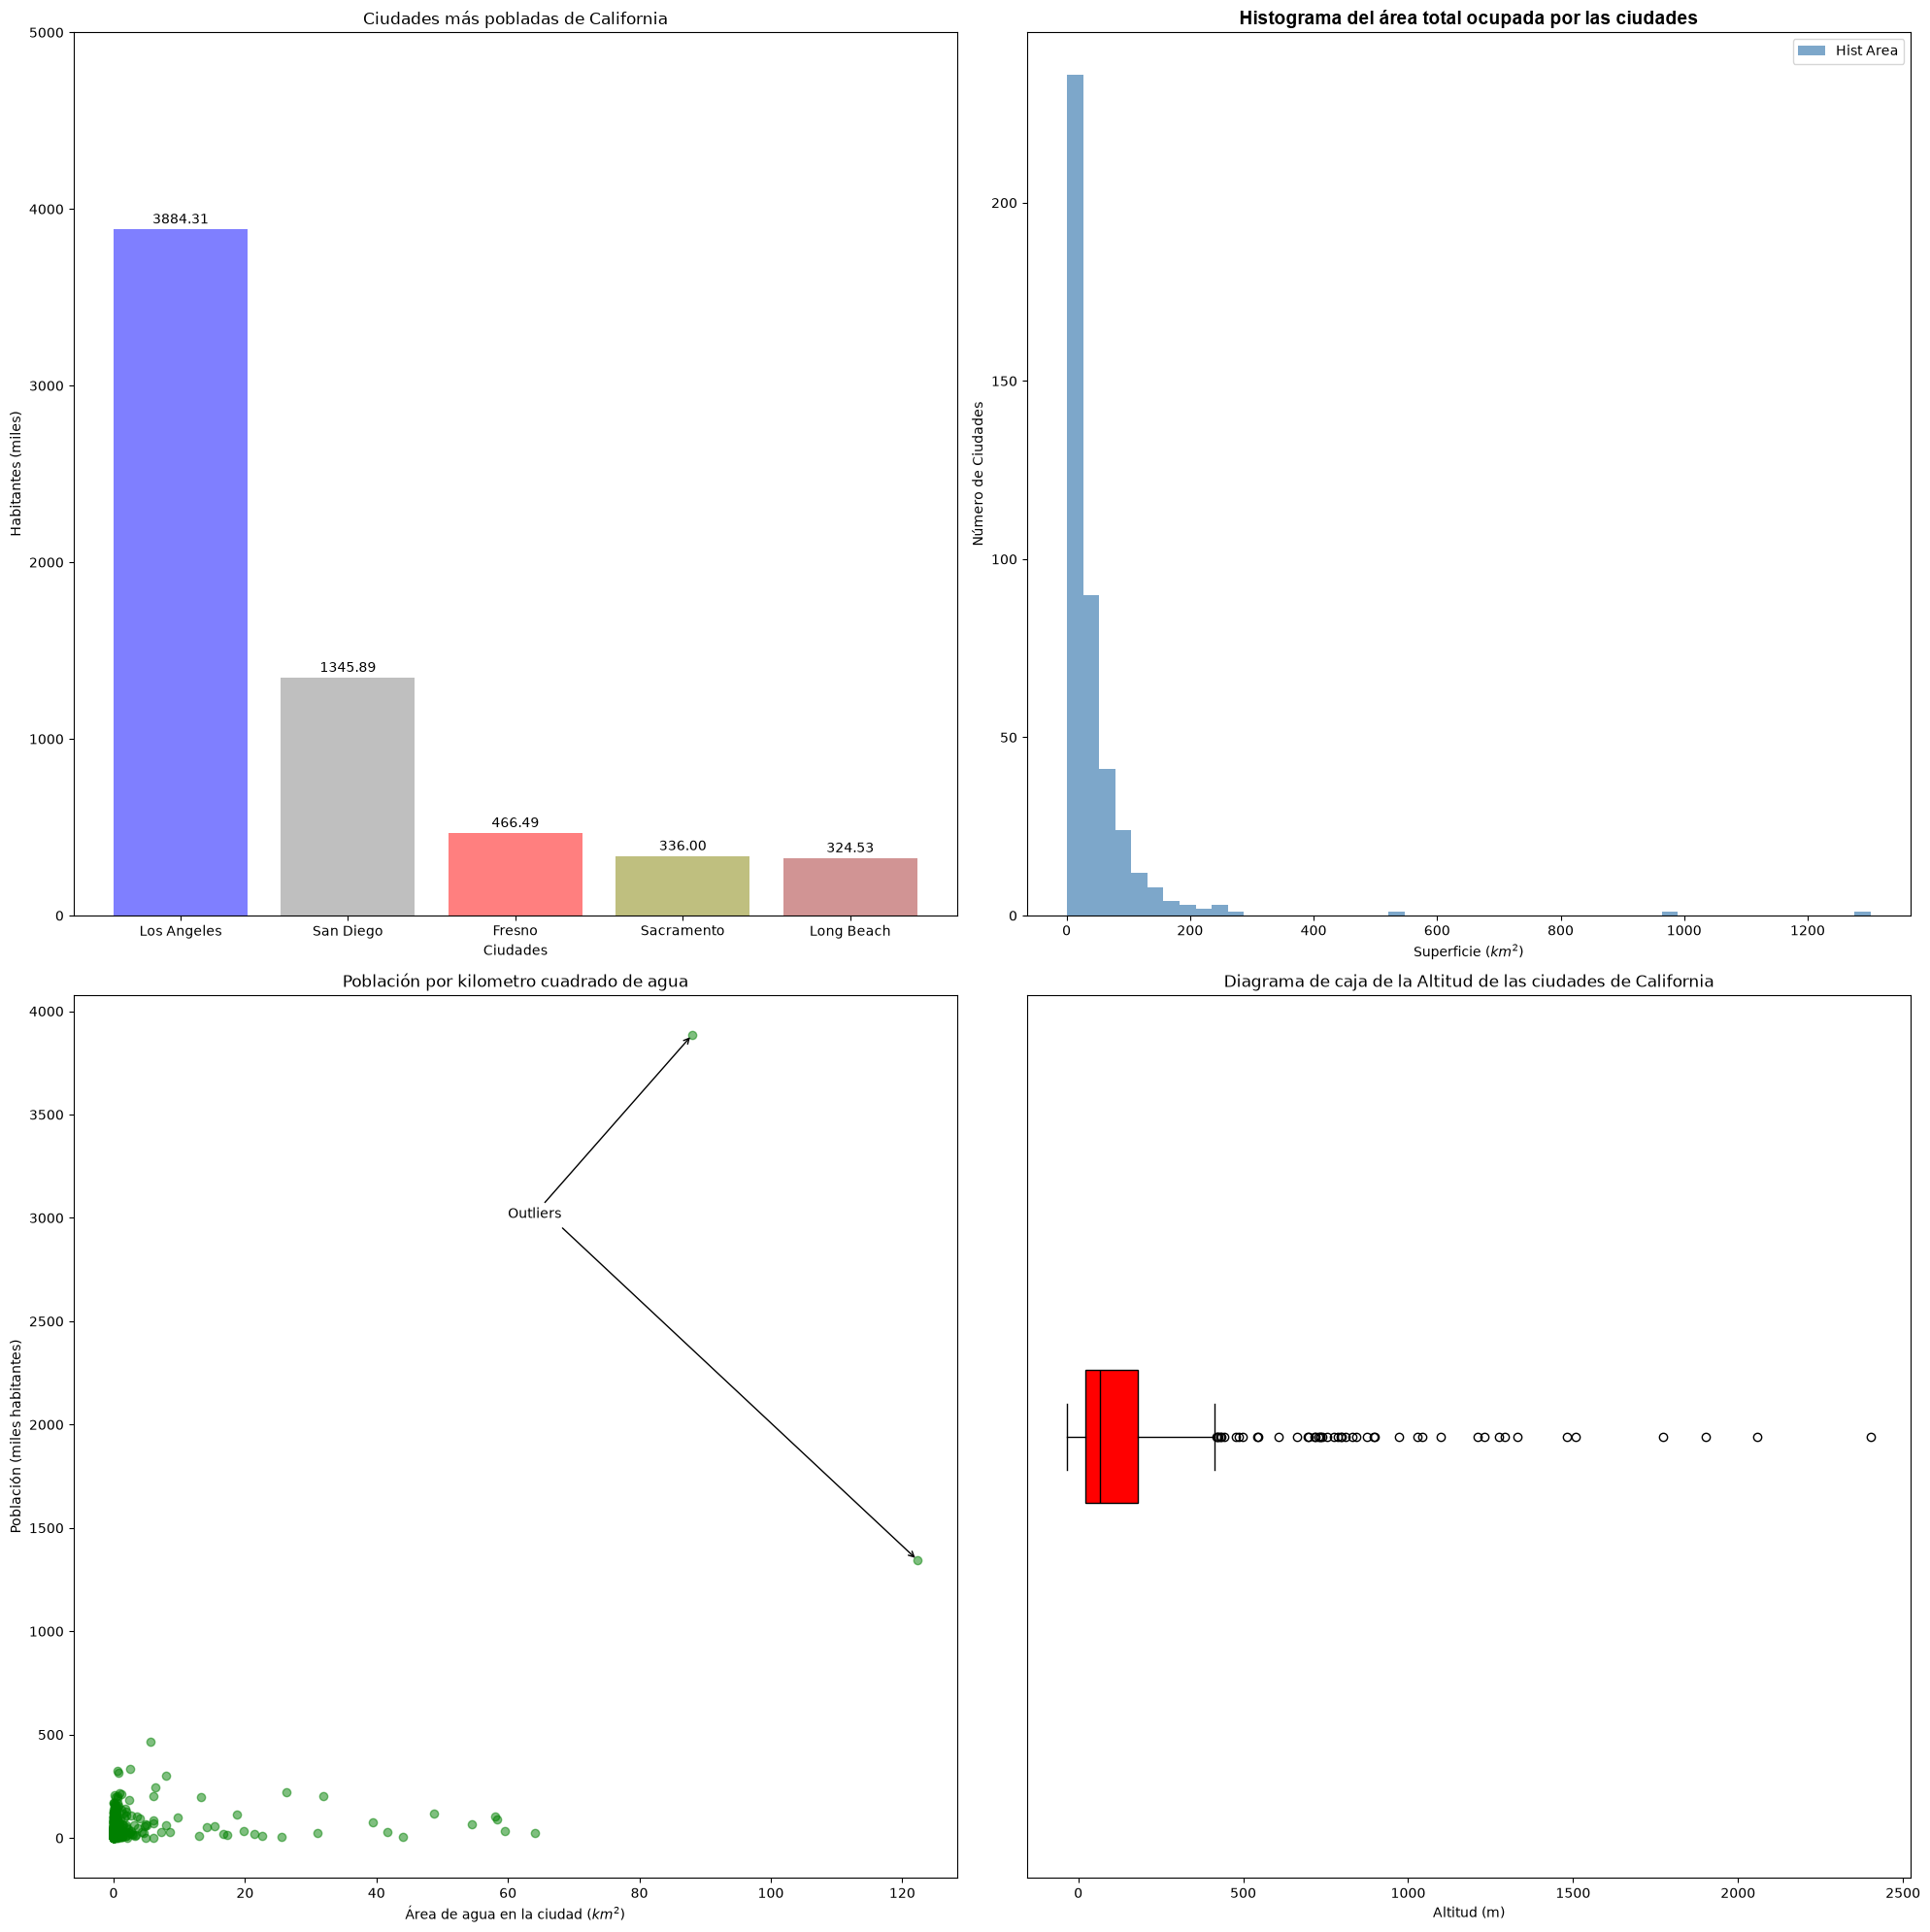

In [51]:
figura_conjunta(df_cal, df_ciudades, df_dispersion, outliers)

#### #1.3

Graba la figura en un archivo .png y sube el archivo a tu repositorio personal junto con el notebook.

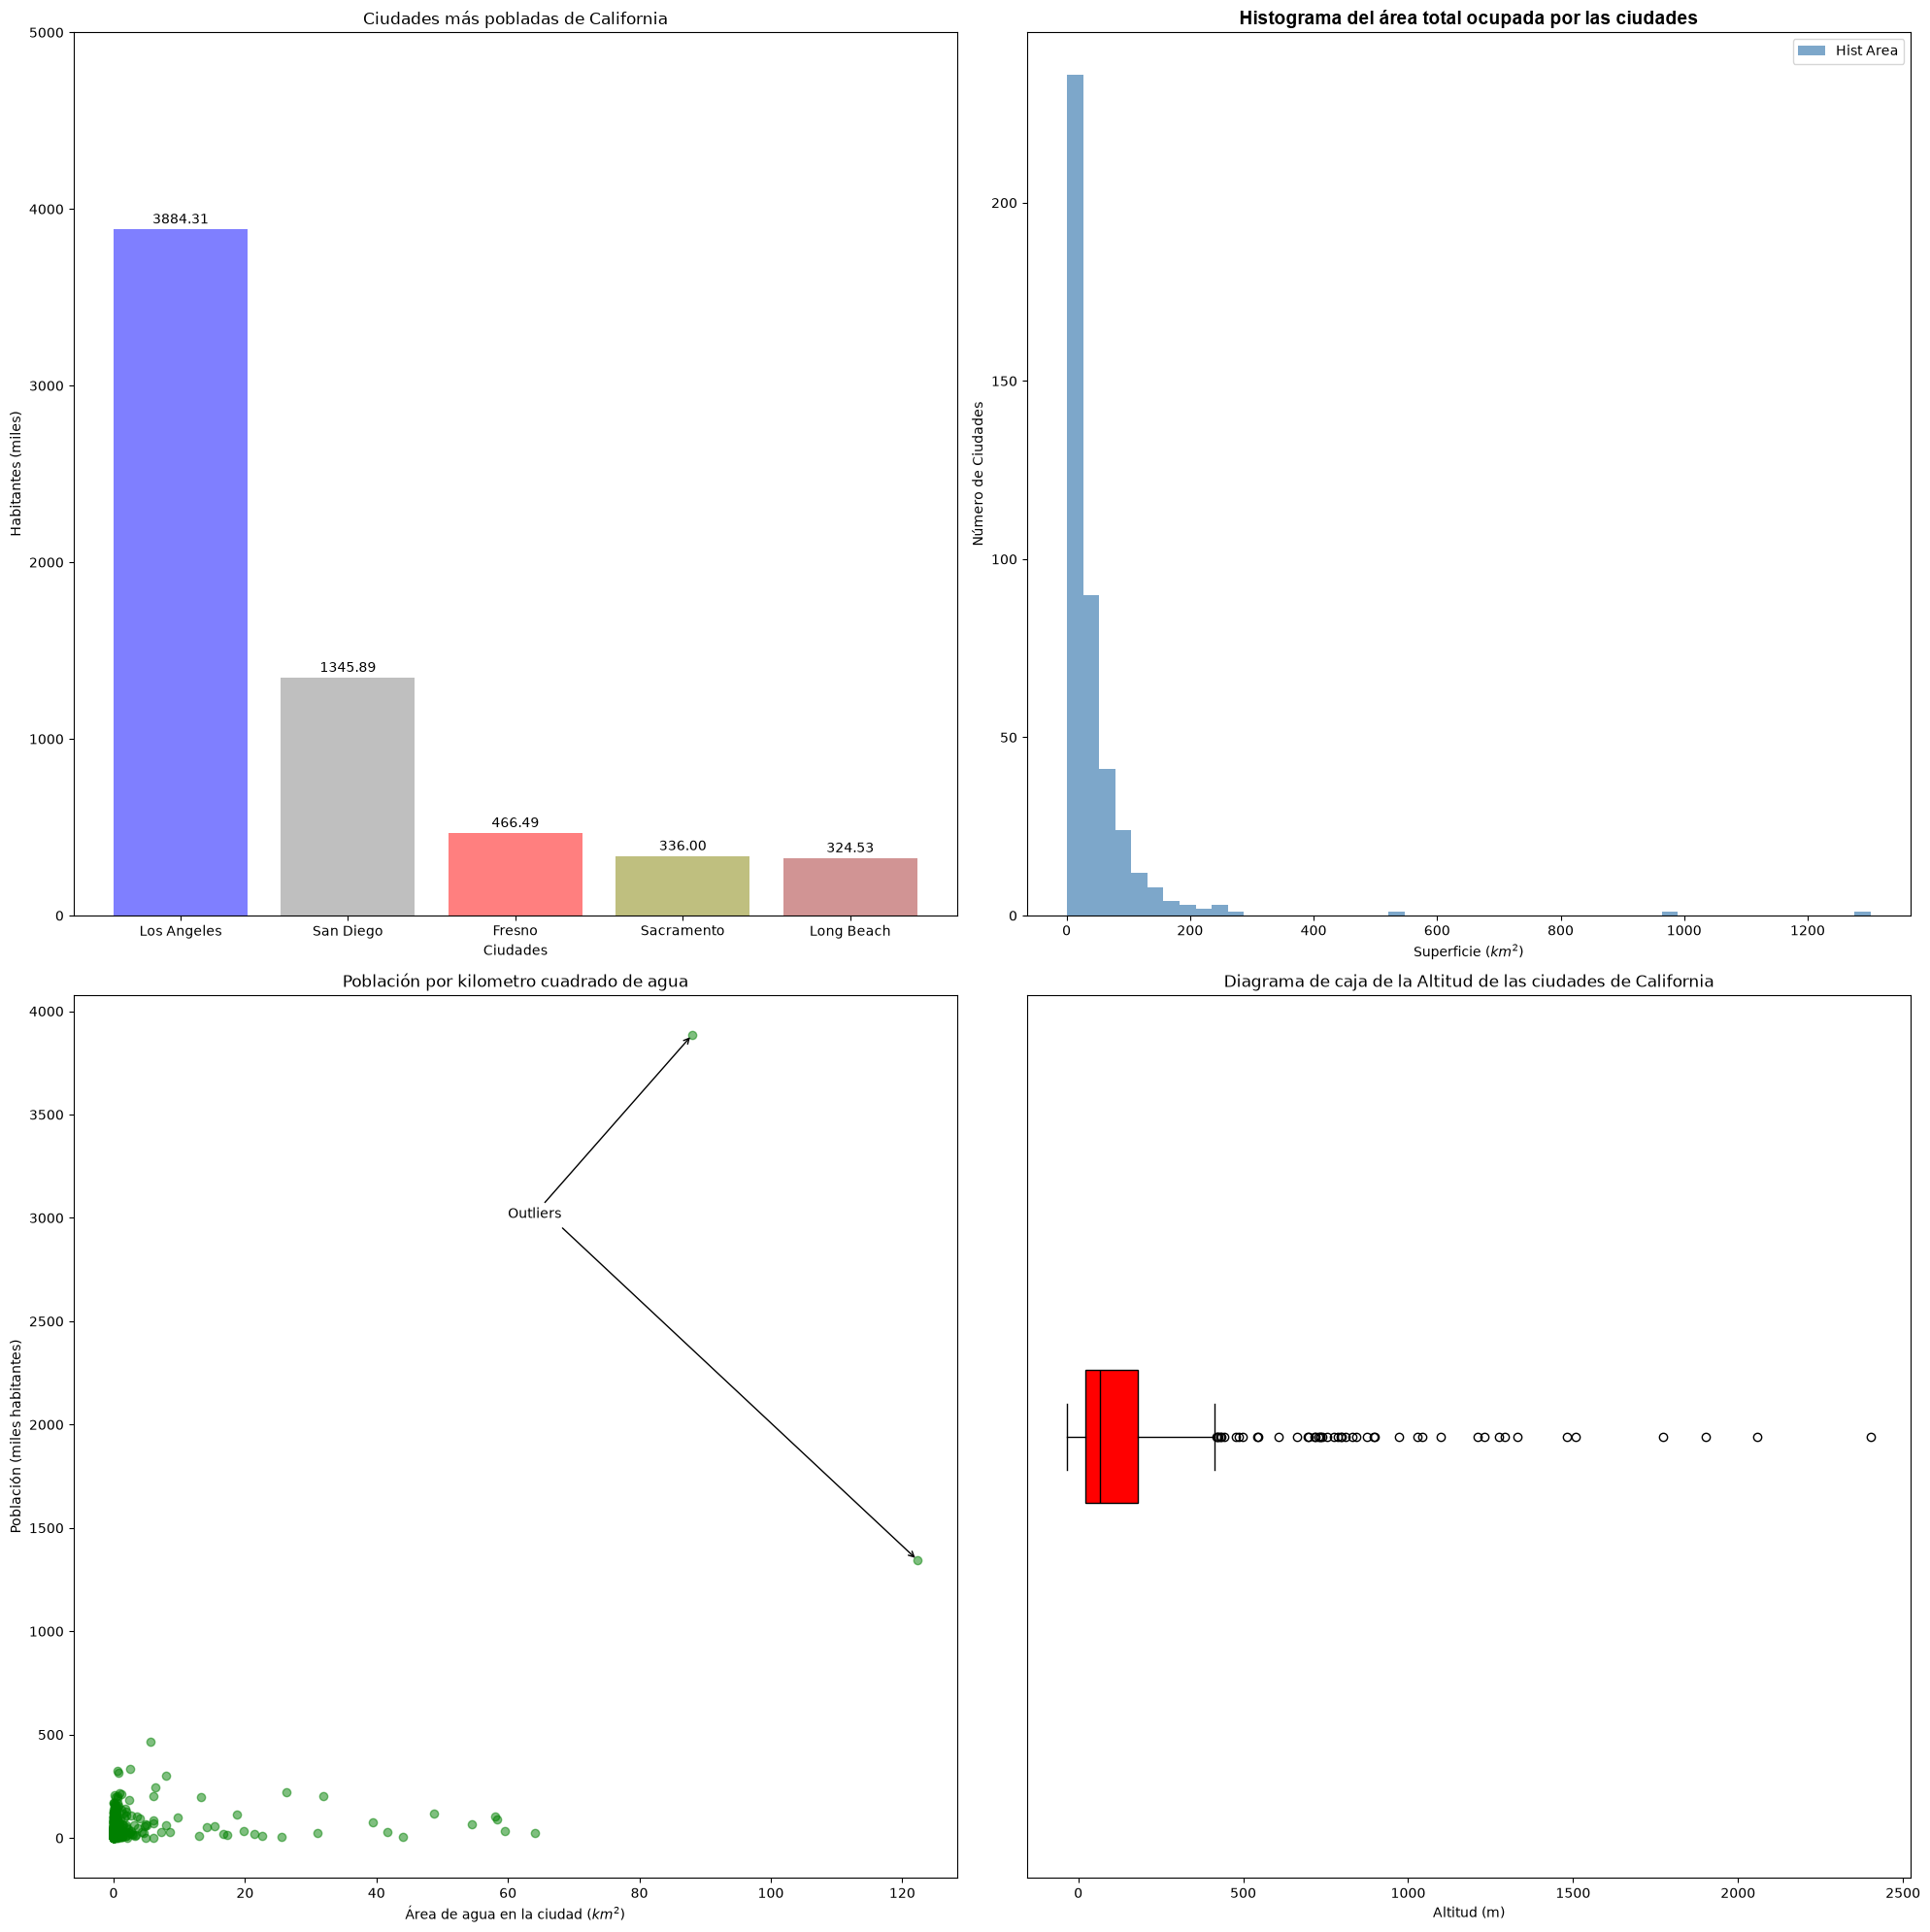

In [53]:
figura_conjunta(df_cal, df_ciudades, df_dispersion, outliers, guardar=True)